In [ ]:
# Comment the following lines if you're not in colab:
from google.colab import drive
drive.mount('/content/drive')
# If you're in colab, cd to your own working directory here:
%cd ..//..//content//drive//MyDrive//Colab-Notebooks//HY-673-Tutorials//Tutorial-4

Mounted at /content/drive
/content/drive/MyDrive/Colab-Notebooks/HY-673-Tutorials/Tutorial-4


In [ ]:
!pip install torchinfo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch as tc
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torchinfo import summary

# <u>Convolutional Neural Networks</u>

Convolutional Neural Networks (CNNs) are neural network architectures that rely mainly on **convolutional layers**.

These layers act as **parametric sliding windows** that scan the input and extract **local features**. Unlike linear layers, where each input element has a different weight, convolutional layers apply the **same set of weights across different regions of the input**.

This weight sharing allows CNNs to learn **position-invariant features**. For example, when processing images, convolutional layers may detect patterns such as **eyes or hands**, regardless of their position in the image.

Below is an illustration of how a **2D convolutional filter** operates:

https://miro.medium.com/max/790/1*1okwhewf5KCtIPaFib4XaA.gif

**For deeper insights, refer to the PDF of the second tutorial of the course.**

In [ ]:
seed = 42
np.random.seed(seed)
tc.manual_seed(seed)

device = tc.device("cuda" if tc.cuda.is_available() else "cpu")

batch_size = 16
lr = 5e-4
adam_betas = (0.9, 0.9)
n_epochs = 6

In [ ]:
datapath = 'data'

# load the MNIST dataset:
data_train = MNIST(
    root = datapath,
    train = True, # this we'll use for training the model
    transform = ToTensor(),
    download=True
)
data_test = MNIST(
    root = datapath,
    train = False, # and this for testing
    transform = ToTensor(),
    download=True
)

# initialize train set and test set loaders:
train_loader = DataLoader(
    data_train,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True,
    num_workers=2
)

test_loader = DataLoader(
    data_test,
    batch_size=32,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

### <u>Output Dimensionality</u>

Unlike linear layers, which can have any size you want, convolutional layers require more care when defining them, since the way the output dimensionality is determined is not as straightforward.  

More specifically, the formulae to determine the output height and width ($H_{out}$, $W_{out}$) of a channel can be found in the PyTorch documentation:  
https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html  

In our case, the convolutional layers use the same parameters along both spatial dimensions (e.g., `kernel_size[0] = kernel_size[1]`), so the same calculation applies to both height and width.

$H_{out} = \left\lfloor \dfrac{H_{in} + (2 \times \text{padding}[0]) - \text{dilation}[0] \times (\text{kernel_size}[0] - 1) - 1}{\text{stride}[0]} + 1 \right\rfloor$

$W_{out} = \left\lfloor \dfrac{W_{in} + (2 \times \text{padding}[1]) - \text{dilation}[1] \times (\text{kernel_size}[1] - 1) - 1}{\text{stride}[1]} + 1 \right\rfloor$

Let's apply the formula to the first layer: we have a $28 \times 28$ input image (so the same calculation holds for both height and width), a kernel of size $3$, padding equal to $1$, stride equal to $1$, and dilation equal to $1$:

$\dfrac{28 + (2 \times 1) - 1 \times (3 - 1) - 1}{1} + 1 = 28 + 2 - 2 - 1 + 1 = 28$,

so the output dimension is the same as the input dimension.

What about the third layer? There, we have a $7 \times 7$ input image, a kernel of size $2$, padding equal to $1$, stride equal to $1$, and a dilation of $2$:

$\dfrac{7 + (2 \times 1) - 2 \times (2 - 1) - 1}{1} + 1 = 7 + 2 - 2 - 1 + 1 = 7$,

so the dimensionality does not change here either.

Regarding the calculation of trainable parameters, you can check the documentation or the PDF document provided in the second tutorial.

### <u>Simple 2D CNN Example for MNIST Classification</u>

Below is a simple CNN architecture that we will use to classify MNIST digits. The network consists of three convolutional layers followed by max-pooling operations that progressively reduce the spatial resolution while increasing the number of feature maps. Finally, two fully connected layers map the extracted features to the output classes:

In [ ]:
class SimpleCNN(nn.Module):

    def __init__(self, n_classes=10):
        super(SimpleCNN, self).__init__()

        self.n_classes = n_classes

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1,
            dilation=1
        )
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1,
            dilation=1
        )
        self.conv3 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=2,
            stride=1,
            padding=1,
            dilation=2
        )
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )  # non-parametric, same object can be used

        self.fc1 = nn.Linear(
            in_features=64*3*3,
            out_features=32
        )
        self.fc2 = nn.Linear(
            in_features=32,
            out_features=self.n_classes
        )

    def forward(self, x):          # dimension analysis:
        x = F.relu(self.conv1(x))  # 1x28x28  --> 16x28x28
        x = self.pool(x)           # 16x28x28 --> 16x14x14
        x = F.relu(self.conv2(x))  # 16x14x14 --> 32x14x14
        x = self.pool(x)           # 32x14x14 --> 32x7x7
        x = F.relu(self.conv3(x))  # 32x7x7   --> 64x7x7
        x = self.pool(x)           # 64x7x7   --> 64x3x3
        x = x.view(-1, 64 * 3 * 3) # 64x3x3   --> 64*3*3
        x = F.relu(self.fc1(x))    # 64*3*3   --> 32
        x = self.fc2(x)            # 32       --> 10
        return x

Confirm that the data loaders work, and visualize a sample:

input.shape  = torch.Size([16, 1, 28, 28])
labels.shape = torch.Size([16])



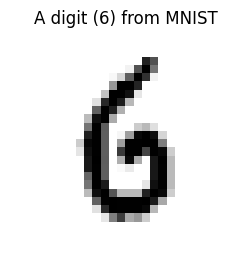

In [ ]:
x1_batch, y1_batch = next(iter(train_loader))
x1_batch, y1_batch = x1_batch.to(device), y1_batch.to(device)
print(f"input.shape  = {x1_batch.shape}\nlabels.shape = {y1_batch.shape}\n")

plt.figure(figsize=(3,3))
plt.imshow(x1_batch[-1, 0].cpu(), cmap='binary')
plt.axis('off')
plt.title(f"A digit ({y1_batch[-1]}) from MNIST")
plt.show()
plt.close()

Sanity checks:

In [ ]:
model = SimpleCNN(n_classes=10).to(device)
out = model(x1_batch)
print(f"output.shape = {out.shape}")
print(summary(model, input_size=x1_batch[0].shape, device=device))

output.shape = torch.Size([16, 10])
Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [1, 10]                   --
├─Conv2d: 1-1                            [16, 28, 28]              160
├─MaxPool2d: 1-2                         [16, 14, 14]              --
├─Conv2d: 1-3                            [32, 14, 14]              4,640
├─MaxPool2d: 1-4                         [32, 7, 7]                --
├─Conv2d: 1-5                            [64, 7, 7]                8,256
├─MaxPool2d: 1-6                         [64, 3, 3]                --
├─Linear: 1-7                            [1, 32]                   18,464
├─Linear: 1-8                            [1, 10]                   330
Total params: 31,850
Trainable params: 31,850
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 5.87
Input size (MB): 0.00
Forward/backward pass size (MB): 0.18
Params size (MB): 0.13
Estimated Total Size (MB): 0.31


Accuracy helper function:

In [ ]:
def model_accuracy(data_loader):

    n_total = 0
    n_correct = 0

    for x_batch_, y_batch_ in data_loader:
        x_batch_ = x_batch_.to(device)
        y_batch_ = y_batch_.to(device)
        logits_batch_ = model(x_batch_)  # model's output scores
        n_total += len(y_batch_)
        n_correct += sum(logits_batch_.argmax(axis=-1) == y_batch_).item()
    return n_correct / n_total

acc_train = model_accuracy(train_loader)
print(
    f"Accuracies before training:\n Train = {acc_train:.4f}\n"
    f" Test  = {model_accuracy(test_loader):.4f}"
)

Accuracies before training:
 Train = 0.0987
 Test  = 0.0980


Loss function and optimizer:

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = tc.optim.Adam(params=model.parameters(), lr=lr, betas=adam_betas)

Training loop:

In [ ]:
accuracies_train = []

for epoch in range(n_epochs):

    for i, (x_batch, y_batch) in enumerate(train_loader):

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits_batch = model(x_batch)
        loss_batch = loss_fn(logits_batch, y_batch)
        loss_batch.backward()
        optimizer.step()

    # evaluate the model at the end of each epoch
    with tc.no_grad():
        acc_train = model_accuracy(train_loader)
        print(f"Epoch {epoch+1:03d} | train set accuracy = {acc_train:.4f}")
        accuracies_train.append(acc_train)

Epoch 001 | train set accuracy = 0.9578
Epoch 002 | train set accuracy = 0.9817
Epoch 003 | train set accuracy = 0.9846
Epoch 004 | train set accuracy = 0.9897
Epoch 005 | train set accuracy = 0.9915
Epoch 006 | train set accuracy = 0.9926


Results:

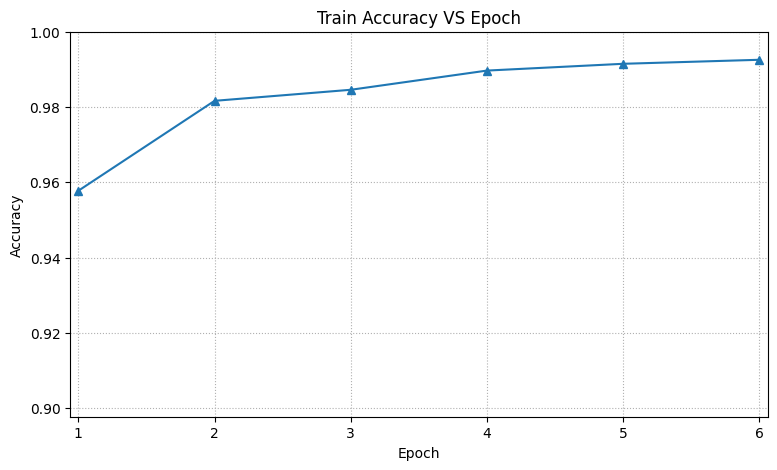

In [ ]:
epoch_ax = np.arange(start=1, stop=n_epochs+1, step=1)
plt.figure(figsize=(9,5))
plt.plot(epoch_ax, accuracies_train, '^-')
plt.grid(linestyle=':')
e = 0.06
plt.ylim([min(accuracies_train)-e, min(max(accuracies_train)+e, 1.00)])
plt.xlim([1-e, n_epochs+e])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train Accuracy VS Epoch")
plt.show()
plt.close()

In [ ]:
print(
    f"Accuracies after training:\n Train = {model_accuracy(train_loader):.4f}\n"
    f" Test  = {model_accuracy(test_loader):.4f}"
)

Accuracies after training:
 Train = 0.9926
 Test  = 0.9895


Compared with our previous notebook using the MLP classifier, the CNN achieved:

- **40% fewer trainable parameters**
- **slightly better accuracy (~3%)**
- **shorter training time per epoch**
- **roughly half the epochs required for convergence**

Finally, a standard way to save the model's weights is:

In [ ]:
tc.save(model.state_dict(), f"saved_models/CNN.pt")

# <u>Homework (optional)</u>

- How sensitive is this model to **random initialization**?
- Include a **validation set** (as in the previous notebook) and use it to tune the network hyperparameters.
- Try to reduce the **number of trainable parameters**, compromising accuracy as little as possible.
- Check whether the model correctly classifies digits generated from a **GMM**, like in our previous tutorial.